In [1]:
import ipywidgets as widgets
from IPython.display import display
import os

box_layout = widgets.Layout(
    display="flex",
    flex_flow="column",
    align_items="center",
    border="1px solid #E0E0E0",
    width="400px",
    padding="25px",
    border_radius="10px"
)

button_layout = widgets.Layout(width="100%", height="40px")

upload_layout = widgets.Layout(width="100%")

title = widgets.HTML(
    "<h3 style='margin-bottom:10px;'>Upload CSV Files 👇</h3>"
)

subtitle = widgets.HTML(
    "<p style='color:gray; margin-top:0;'>Select one or more CSV files to upload and save</p>"
)

train_uploader = widgets.FileUpload(
    accept='.csv',
    multiple=True,
    layout=upload_layout
)

save_button = widgets.Button(
    description='Save Files',
    button_style='primary',
    icon='save',
    layout=button_layout
)

status = widgets.HTML("<p style='color:gray;'>Waiting for upload...</p>")

output = widgets.Output()

def save_files(change=None):
    with output:
        output.clear_output()
        
        if train_uploader.value:
            saved_files = []
            for filename, file_info in train_uploader.value.items():
                with open(filename, "wb") as f:
                    f.write(file_info['content'])
                saved_files.append(filename)
            
            status.value = f"<p style='color:green;'>Saved {len(saved_files)} file(s) 👍</p>"
        else:
            status.value = "<p style='color:red;'>⚠️ No files uploaded yet</p>"

train_uploader.observe(save_files, names='value')

save_button.on_click(save_files)

card = widgets.VBox(
    [title, subtitle, train_uploader, save_button, status],
    layout=box_layout
)

display(card)
display(output)

Output()

In [2]:
import matplotlib.pyplot as plot
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('file.csv')

In [4]:
df.sample(4)

,cgpa,package
87,8.09,3.55
78,6.59,2.21
181,8.22,3.89
99,6.61,3.24


Text(0, 0.5, 'Package')

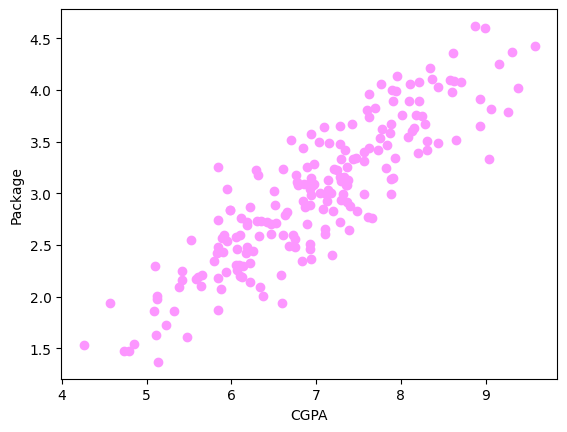

In [34]:
plot.scatter(df['cgpa'], df['package'], color="#fc96ff")
plot.xlabel('CGPA')
plot.ylabel('Package')

## **Implementing Simple Linear Regression**

In [6]:
x = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [7]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 40
)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

lr.fit(xtrain, ytrain)

LinearRegression()

In [22]:
lr.predict(xtest)

array([3.08765691, 3.54491102, 4.21906771, 2.94696334, 3.18731486,
       3.09938138, 2.94110111, 3.140417  , 3.08765691, 3.18731486,
       3.13455477, 2.98213673, 3.07593245, 3.79112477, 2.68316289,
       3.55663548, 3.6152578 , 2.54833155, 2.34315343, 2.37832682,
       2.50729593, 2.40177575, 1.72761906, 2.90006548, 3.21076379,
       3.00558566, 2.98799896, 2.82385647, 2.73006075, 2.83558093,
       2.64212727, 2.47798477, 3.99044066, 4.37734798, 2.7945453 ,
       3.9611295 , 2.49557147, 2.09693968, 2.73592298, 2.23763325])

In [24]:
ytest.values

array([2.61, 2.99, 3.33, 2.87, 2.72, 2.93, 3.09, 2.83, 2.66, 3.48, 2.4 ,
       3.04, 3.64, 3.42, 2.72, 3.15, 3.76, 2.48, 2.48, 2.43, 2.76, 2.24,
       1.48, 3.08, 2.99, 3.28, 2.98, 2.82, 3.02, 2.49, 2.73, 2.26, 3.52,
       4.37, 2.6 , 3.98, 2.2 , 2.25, 2.89, 2.21])

Text(0, 0.5, 'Package')

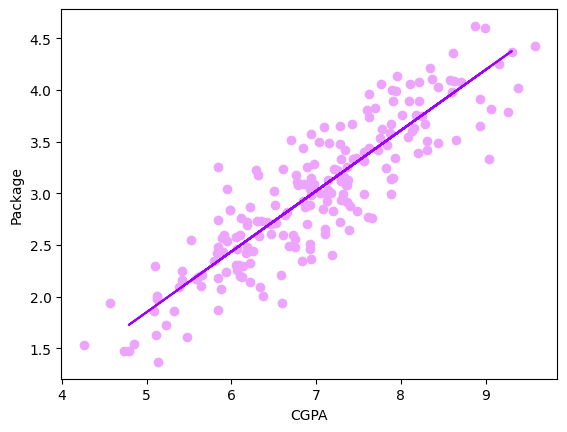

In [31]:
plot.scatter(df['cgpa'], df['package'], color="#eda4ff")
plot.plot(xtest, lr.predict(xtest), color="#9d00ff")
plot.xlabel('CGPA')
plot.ylabel('Package')

In [36]:
slope = lr.coef_

In [37]:
intercept = lr.intercept_

In [38]:
print("Slope : ", slope)
print("Intercept : ", intercept)

Slope :  [0.58622321]
Intercept :  -1.080390137131896
